Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0854 - loss: 2.3466 - val_accuracy: 0.1897 - val_loss: 2.3376
Loss = 2.3375613689422607
Accuracy = 0.18965516984462738
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


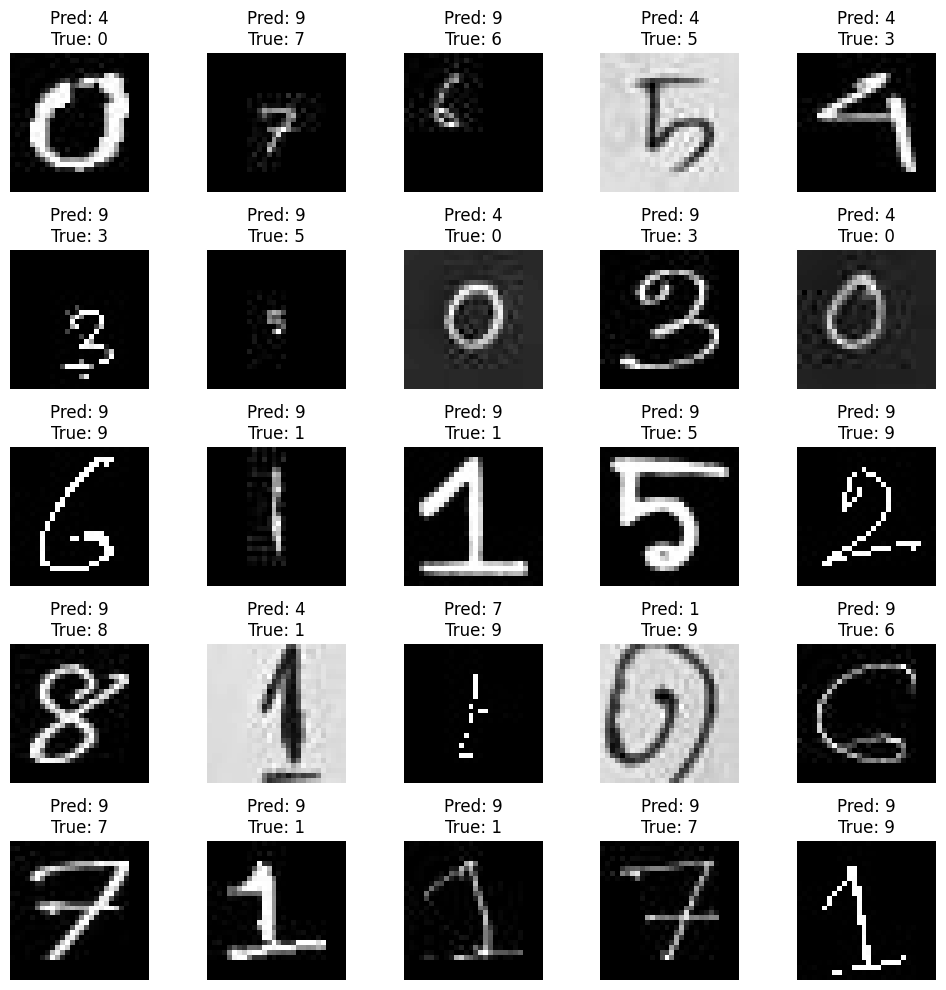

In [ ]:
# FCFNN Training Using Existing .npy Dataset Files

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten

# 1. Load Pre-Saved Dataset

x_train = np.load("Data/my_dataset/x_train.npy")
y_train = np.load("Data/my_dataset/y_train.npy")
x_test  = np.load("Data/my_dataset/x_test.npy")
y_test  = np.load("Data/my_dataset/y_test.npy")

# Normalize (if not already normalized)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Ensure correct shape (N,28,28,1)
if len(x_train.shape) == 3:
    x_train = x_train.reshape(-1, 28, 28, 1)
    x_test  = x_test.reshape(-1, 28, 28, 1)

# 2. Build FCFNN Model

num_classes = 10

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train Model

history = model.fit(
    x_train, y_train,
    epochs=1,
    batch_size=3200,
    validation_data=(x_test, y_test),
    verbose=1
)

# 4. Evaluate Model

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Loss = {loss}")
print(f"Accuracy = {accuracy}")

# 5. Predict & Plot 25 Results

predY = model.predict(x_test)
pred_labels = predY.argmax(axis=1)

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {pred_labels[i]}\nTrue: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()